In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc

In [129]:
df=pd.read_csv("d:\python\diabetes.csv")
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\p'
<>:1: SyntaxWarning: invalid escape sequence '\p'
C:\Users\momin\AppData\Local\Temp\ipykernel_6704\3094461427.py:1: SyntaxWarning: invalid escape sequence '\p'
  df=pd.read_csv("d:\python\diabetes.csv")


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [130]:
df.isnull()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
763,False,False,False,False,False,False,False,False,False
764,False,False,False,False,False,False,False,False,False
765,False,False,False,False,False,False,False,False,False
766,False,False,False,False,False,False,False,False,False


In [131]:
df.isnull().keys()

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [132]:
x = df.iloc[::-1].values
y = df.iloc[:,-1].values
print(y.shape)
x.shape

(768,)


(768, 9)

In [133]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.20, random_state =32)

In [134]:
sc_x = StandardScaler()
x_train = sc_x.fit_transform(x_train)
x_test = sc_x.transform(x_test)

In [135]:

model_logistic = LogisticRegression (C=2)
model_logistic.fit(x_train, y_train)

y_pred_logistic = model_logistic.decision_function(x_test)



In [136]:
dt = DecisionTreeClassifier(max_depth=50)
dt.fit(x_train,y_train)
y_pred_dt = dt.predict_proba(x_test)

In [137]:
rfr = RandomForestClassifier(n_estimators=100)
rfr.fit(x_train,y_train)
y_pred_rfr = rfr.predict_proba (x_test)

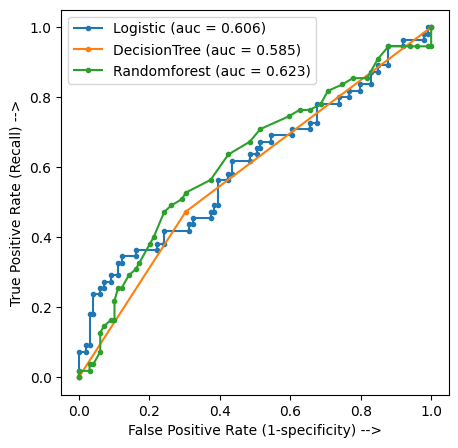

In [138]:
logistic_fpr, logistic_tpr, threshold = roc_curve(y_test, y_pred_logistic)
auc_logistic = auc(logistic_fpr, logistic_tpr)
dt_fpr, dt_tpr, threshold = roc_curve(y_test, y_pred_dt[:,1:2])
auc_dt = auc(dt_fpr, dt_tpr)
rfr_fpr, rfr_tpr, threshold = roc_curve(y_test, y_pred_rfr[:,1:2])
auc_rfr = auc(rfr_fpr, rfr_tpr)

plt.figure(figsize=(5, 5), dpi=100)
plt.plot(logistic_fpr, logistic_tpr, marker='.', label='Logistic (auc = %0.3f)' % auc_logistic)
plt.plot(dt_fpr, dt_tpr, marker='.', label='DecisionTree (auc = %0.3f)' % auc_dt)
plt.plot(rfr_fpr, rfr_tpr, marker='.', label='Randomforest (auc = %0.3f)' % auc_rfr)

plt.xlabel('False Positive Rate (1-specificity) -->')
plt.ylabel('True Positive Rate (Recall) -->')


plt.legend()
plt.show()


